<a href="https://colab.research.google.com/github/garam827/LLM_Study/blob/main/%EB%9E%AD%EA%B7%B8%EB%9E%98%ED%94%84_%EC%9D%B8%ED%84%B0%EB%84%B7%EA%B2%80%EC%83%89.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
%pip install langchain
%pip install langgraph
%pip install langchain-openai
%pip install langchain_community
%pip install -U ddgs

In [14]:
from google.colab import userdata

# OpenRouter API Key (assuming it's stored in Colab secrets)
OPENROUTER_API_KEY = userdata.get('OPEN_ROUTER')

In [15]:
from langchain_openai import ChatOpenAI

# 모델 초기화
model = ChatOpenAI(
    model  = "openai/gpt-oss-120b:free",
    openai_api_key = OPENROUTER_API_KEY,
    openai_api_base = "https://openrouter.ai/api/v1"
)

In [16]:
# 상태 설정

from typing import Annotated # annotated는 타입 힌트를 사용할 때 사용하는 함수
from typing_extensions import TypedDict # TypedDict는 딕셔너리 타입을 정의할 때 사용하는 함수

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):
    """
    State 클래스는 TypedDict를 상속받습니다.

    속성:
        messages (Annotated[list[str], add_messages]): 메시지들은 "list" 타입을 가집니다.
        주석에 있는 'add_messages' 함수는 이 상태 키가 어떻게 업데이트되어야 하는지를 정의합니다.
        (이 경우, 메시지를 덮어쓰는 대신 리스트에 추가합니다)
    """
    messages: Annotated[list[str], add_messages]

# StateGraph 클래스를 사용하여 State 타입의 그래프를 생성합니다.
graph_builder = StateGraph(State)

In [17]:
# 도구 등록
from langchain_core.tools import tool
from datetime import datetime
import pytz
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper

import bs4
from langchain_community.document_loaders import WebBaseLoader

# 도구 함수 정의
@tool
def get_current_time(timezone: str, location: str) -> str:
    """현재 시각을 반환하는 함수."""
    try:
        tz = pytz.timezone(timezone)
        now = datetime.now(tz).strftime("%Y-%m-%d %H:%M:%S")
        result = f'{timezone} ({location}) 현재시각 {now}'
        # print(result)
        return result
    except pytz.UnknownTimeZoneError:
        return f"알 수 없는 타임존: {timezone}"

@tool
def get_web_search(query: str, search_period: str='m') -> str:
    """
    웹 검색을 수행하는 함수.

    Args:
        query (str): 검색어
        search_period (str): 검색 기간 (e.g., "w" for past week (default), "m" for past month, "y" for past year, "d" for past day)

    Returns:
        str: 검색 결과
    """
    wrapper = DuckDuckGoSearchAPIWrapper(
        # region="kr-kr",
        time=search_period
    )

    print('\n-------- WEB SEARCH --------')
    print(query)
    print(search_period)

    search = DuckDuckGoSearchResults(
        api_wrapper=wrapper,
        # source="news",
        results_separator=';\n'
    )

    searched = search.invoke(query)

    for i, result in enumerate(searched.split(';\n')):
        print(f'{i+1}. {result}')

    return searched

# 도구 바인딩
tools = [get_current_time, get_web_search]

In [18]:
# 현재 시각 얻는 도구 테스트
tools[0].invoke({"timezone": "Asia/Seoul", "location": "서울"})

'Asia/Seoul (서울) 현재시각 2026-04-21 00:06:46'

In [19]:
# 웹 검색 도구 테스트
tools[1].invoke({"query": "파이썬", "search_period": "m"})


-------- WEB SEARCH --------
파이썬
m
1. snippet: 혼자 공부하는 파이썬. 59 видео 1 039 825 просмотров Обновлен 23 сент. 2021 г. Предпросмотр.혼자 공부하는 파이썬 27강 - break 키워드와 continue 키워드., title: 혼자 공부하는 파이썬 - YouTube, link: https://www.youtube.com/playlist?list=PLBXuLgInP-5kr0PclHz1ubNZgESmliuB7
2. snippet: 『혼자 만들면서 공부하는 파이썬』 시작하기 - 파이썬 개발 환경 설정 완벽 가이드 (VS Code + 가상환경). ModuleNotFoundError 등 VS Code 파이썬 가상환경 오류, 5분 컷으로 끝내기!, title: 혼자 만들면서 공부하는 파이썬(feat. 한빛 미디어 혼만공...) - YouTube, link: https://www.youtube.com/playlist?list=PLID7cC3lN2TF4D1uUL3gYoK6VE7WlorbQ
3. snippet: 파이썬 라즈베리파이 IoT프로젝트-원격모니터링 자동차Hình thu nhỏ khóa học.ChatGPT 100% 활용하여 배우는 파이썬 네트워크 프로그래밍 A to ZHình thu nhỏ khóa học., title: [입문반] 핵심 파이썬 with Cursor 강의 | Joe (브리쳐스) - 인프런, link: https://www.inflearn.com/course/핵심-파이썬-cursor
4. snippet: 프로그래밍. 파이썬 문제 풀이 100. 파이썬 코딩 도장. 참여자. 일반. 게시판 공지사항. FAQ. Thonny로 파이썬 실습하세요! Unit 1. 소프트웨어 교육과 파이썬., title: 파이썬 코딩 도장: Thonny로 파이썬 실습하세요!, link: https://dojang.io/mod/forum/discuss.php?d=1550


'snippet: 혼자 공부하는 파이썬. 59 видео 1 039 825 просмотров Обновлен 23 сент. 2021 г. Предпросмотр.혼자 공부하는 파이썬 27강 - break 키워드와 continue 키워드., title: 혼자 공부하는 파이썬 - YouTube, link: https://www.youtube.com/playlist?list=PLBXuLgInP-5kr0PclHz1ubNZgESmliuB7;\nsnippet: 『혼자 만들면서 공부하는 파이썬』 시작하기 - 파이썬 개발 환경 설정 완벽 가이드 (VS Code + 가상환경). ModuleNotFoundError 등 VS Code 파이썬 가상환경 오류, 5분 컷으로 끝내기!, title: 혼자 만들면서 공부하는 파이썬(feat. 한빛 미디어 혼만공...) - YouTube, link: https://www.youtube.com/playlist?list=PLID7cC3lN2TF4D1uUL3gYoK6VE7WlorbQ;\nsnippet: 파이썬 라즈베리파이 IoT프로젝트-원격모니터링 자동차Hình thu nhỏ khóa học.ChatGPT 100% 활용하여 배우는 파이썬 네트워크 프로그래밍 A to ZHình thu nhỏ khóa học., title: [입문반] 핵심 파이썬 with Cursor 강의 | Joe (브리쳐스) - 인프런, link: https://www.inflearn.com/course/핵심-파이썬-cursor;\nsnippet: 프로그래밍. 파이썬 문제 풀이 100. 파이썬 코딩 도장. 참여자. 일반. 게시판 공지사항. FAQ. Thonny로 파이썬 실습하세요! Unit 1. 소프트웨어 교육과 파이썬., title: 파이썬 코딩 도장: Thonny로 파이썬 실습하세요!, link: https://dojang.io/mod/forum/discuss.php?d=1550'

In [20]:
#  도구 목록 확인하기
for tool in tools:
    print(tool.name, tool)

get_current_time name='get_current_time' description='현재 시각을 반환하는 함수.' args_schema=<class 'langchain_core.utils.pydantic.get_current_time'> func=<function get_current_time at 0x7c6baa8f8180>
get_web_search name='get_web_search' description='웹 검색을 수행하는 함수.\n\nArgs:\n    query (str): 검색어\n    search_period (str): 검색 기간 (e.g., "w" for past week (default), "m" for past month, "y" for past year, "d" for past day)\n\nReturns:\n    str: 검색 결과' args_schema=<class 'langchain_core.utils.pydantic.get_web_search'> func=<function get_web_search at 0x7c6baa8f80e0>


In [21]:
# .bind_tools : 언어 모델에 사용할 도구 연결
model_with_tools = model.bind_tools(tools) # GPT 언어모델에 도구 연결

def generate(state: State):
    """
    주어진 상태를 기반으로 챗봇의 응답 메시지를 생성합니다.

    매개변수:
    state (State): 현재 대화 상태를 나타내는 객체로, 이전 메시지들이 포함되어 있습니다.

    반환값:
    dict: 모델이 생성한 응답 메시지를 포함하는 딕셔너리.
          형식은 {"messages": [응답 메시지]}입니다.
    """
    return {"messages": model_with_tools.invoke(state["messages"])}

graph_builder.add_node("generate", generate)

In [22]:
# 도구 사용하는 노드 클래스 생성
import json
from langchain_core.messages import ToolMessage

class BasicToolNode:
    """
    도구를 실행하는 노드 클래스입니다. 마지막 AIMessage에서 요청된 도구를 실행합니다.
    Attributes:
        tools_by_name (dict): 도구 이름을 키로 하고 도구 객체를 값으로 가지는 사전입니다.
    Methods:
        __init__(tools: list): 도구 객체들의 리스트를 받아서 초기화합니다.
        __call__(inputs: dict): 입력 메시지를 받아서 도구를 실행하고 결과 메시지를 반환합니다.
    """
    """A node that runs the tools requested in the last AIMessage."""

    def __init__(self, tools: list) -> None:    # ①
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):    # ②
        if messages := inputs.get("messages", []):
            # inputs에 messages가 있으면 messages를 가져오고 없으면 빈 리스트를 가져옵니다.
            message = messages[-1]
        else:
            raise ValueError("No message found in input")
        outputs = []
        for tool_call in message.tool_calls:    # ③
            tool_result = self.tools_by_name[tool_call["name"]].invoke(
                tool_call["args"]
            )
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )
        return {"messages": messages + outputs}

tool_node = BasicToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

In [23]:
# 언어 모델이 도구 사용 여부를 판단하도록 라우터 설정
def route_tools(state: State):
    """
    마지막 메시지에 도구 호출이 있는 경우 ToolNode로 라우팅하고,
    그렇지 않은 경우 끝으로 라우팅하기 위해 conditional_edge에서 사용합니다.
    """
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"tool_edge 입력 상태에서 메시지를 찾을 수 없습니다: {state}")
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return END

graph_builder.add_edge(START, "generate")

graph_builder.add_conditional_edges(
    "generate",
    route_tools,
    {"tools": "tools", END: END},
)
# 도구가 호출될 때마다 다음 단계를 결정하기 위해 챗봇으로 돌아갑니다.
graph_builder.add_edge("tools", "generate")
graph = graph_builder.compile()


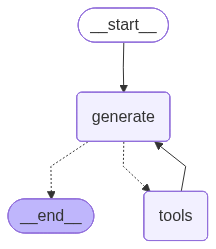

In [24]:
# 그래프 출력하기
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [25]:
# 답변 출력하기
from langchain_core.messages import AIMessageChunk, HumanMessage

inputs = [HumanMessage(content="지금 서울 몇시야?")]

gathered = None

for msg, metadata in graph.stream({"messages": inputs}, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk):
        print(msg.content, end='')

        if gathered is None:
            gathered = msg
        else:
            gathered = gathered + msg

gathered

현재 서울 시간은 **2026년 4월 21일 00시 07분 09초**입니다.

AIMessageChunk(content='현재 서울 시간은 **2026년 4월 21일 00시 07분 09초**입니다.', additional_kwargs={}, response_metadata={'model_provider': 'openai', 'finish_reason': 'tool_callstool_callsstopstop', 'model_name': 'openai/gpt-oss-120b:freeopenai/gpt-oss-120b:freeopenai/gpt-oss-120b:freeopenai/gpt-oss-120b:free'}, id='lc_run--019dab6e-5081-7cb3-9a52-381366f3d677', tool_calls=[{'name': 'get_current_time', 'args': {'location': 'Seoul', 'timezone': 'Asia/Seoul'}, 'id': 'chatcmpl-tool-b2268e2cc5d91d78', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 542, 'output_tokens': 87, 'total_tokens': 629, 'input_token_details': {'audio': 0, 'cache_read': 304}, 'output_token_details': {'audio': 0, 'reasoning': 14}}, tool_call_chunks=[{'name': 'get_current_time', 'args': '{\n  "location": "Seoul",\n  "timezone": "Asia/Seoul"\n}', 'id': 'chatcmpl-tool-b2268e2cc5d91d78', 'index': 0, 'type': 'tool_call_chunk'}], chunk_position='last')

In [26]:
# 프롬프트 설정하고 기사 작성하기
from langchain_core.messages import AIMessageChunk, SystemMessage

about = "서울월드컵 경기장 잔디 문제"

inputs = [SystemMessage(content=f"""
너는 신문기자이다.
최근 {about}에 대해 비판하는 심층 분석 기사를 쓰려고 한다.

- 최근 어떤 이슈가 있는지 검색하고, 사람들이 제일 관심있어 할만한 주제를 선정하고, 왜 선정했는지 말해줘.
- 그 내용으로 원고를 작성하기 위한 목차를 만들고, 목차 내용을 채우기 위해 추가로 검색할 내용을 리스트로 정리해봐.
- 검색할 리스트를 토대로 재검색을 한다.
- 목차에 있는 내용을 작성하기 위해 더 검색이 필요한 정보가 있는지 확인하고, 있다면 추가로 검색해라.
- 검색된 결과에 원하는 정보를 찾지 못했다면 다른 검색어로 재검색해도 좋다.

더 이상 검색할 내용이 없다면, 조선일보 신문 기사 형식으로 최종 기사를 작성하라.
제목, 부제, 리드문, 본문 의 구성으로 작성하라. 본문 내용은 심층 분석 기사에 맞게 구체적이고 깊이 있게 작성해야 한다.

""")]

for msg, metadata in graph.stream({"messages": inputs}, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk):
        print(msg.content, end='')


-------- WEB SEARCH --------
서울월드컵 경기장 잔디 문제 최근 이슈
m
1. snippet: 왜 또 우리 팀 경기장 이름이 갤에서 보이냐? 잔디 이슈 또 터짐? 4 수원삼성박지원 15:46 177 1 잡담 오 금요일 회사 급식 여경옥셰프 짬뽕 5 오리왕v 15:45 33 4 잡담 결국 고통 받는건 팬들이지 아시아나항공 15:45 36 2 잡담 아 박건하 돌대가리 색기때문에 짜증나네 2 ..., title: 왜 또 우리 팀 경기장 이름이 갤에서 보이냐? 잔디 이슈 또 터짐? - 국내축구 - 에펨코리아, link: https://www.fmkorea.com/9703327479
2. snippet: AI가 사용됨 제미나이와 낋여온 서울월드컵경기장 리모델링 뱅가드 2분 전 18 0 0 0 https://fcseoulite.me/free/57695897 복사, title: 제미나이와 낋여온 서울월드컵경기장 리모델링 - 서울라이트, link: https://fcseoulite.me/free/57695897
3. snippet: 문제 해결을 위해 서울시는 지난해부터 본격적인 체계 정비에 나섰다. 가장 먼저 한 일은 '법적 근거 마련'이다. 조례 신설을 통해 기상 악화, 잔디 훼손 우려, 과도한 사용 등을 이유로 시장이 경기장 사용을 제한하거나 금지할 수 있는 법적 토대를 마련했다. '서울월드컵경기장 주경기장 잔디 관리 ..., title: "햇빛도, 바람도 막혔다"…상암 잔디가 '3중고' 버티는 비법 - 뉴스1, link: https://www.news1.kr/local/moi/6139075
4. snippet: 음성재생 설정이동 통신망에서 음성 재생 시 데이터 요금이 발생할 수 있습니다. 글자 수 10,000자 초과 시 일부만 음성으로 제공합니다. 서울월드컵경기장, 폭염·지붕·과밀 대관에 시달려 서울시, 사용 제한하고 하이브리드 잔디 확보·첨단장비 투입 서울월드컵경기장, title: "햇빛도, 바람도 막혔다"…상암 잔디가 '3중고' 버티는 비법,